In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score

In [3]:
data = pd.read_csv('marketing_campaign.csv', sep='\t')
data.shape

(2240, 29)

In [5]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [7]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [9]:
data.isnull().sum()


ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [40]:
def preprocess_data(df):
    df_processed = df.copy()
    df_processed['Income'] = df_processed['Income'].fillna(df_processed['Income'].median())
    df_processed = df_processed.dropna() 
    df_processed['Dt_Customer'] = pd.to_datetime(df_processed['Dt_Customer'], dayfirst=True)
    df_processed['Customer_Age'] = 2024 - df_processed['Year_Birth']  # Assuming current year is 2024
    df_processed['Days_Since_Enrollment'] = (pd.to_datetime('2024-01-01') - df_processed['Dt_Customer']).dt.days
    columns_to_drop = ['ID', 'Year_Birth', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue', 'Response']
    df_processed = df_processed.drop(columns=columns_to_drop, errors='ignore')
    
    categorical_cols = ['Education', 'Marital_Status']
    df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)
    
    return df_processed

df_processed = preprocess_data(data)
df_processed

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,58138.0,0,0,58,635,88,546,172,88,88,...,True,False,False,False,False,False,True,False,False,False
1,46344.0,1,1,38,11,1,6,2,1,6,...,True,False,False,False,False,False,True,False,False,False
2,71613.0,0,0,26,426,49,127,111,21,42,...,True,False,False,False,False,False,False,True,False,False
3,26646.0,1,0,26,11,4,20,10,3,5,...,True,False,False,False,False,False,False,True,False,False
4,58293.0,1,0,94,173,43,118,46,27,15,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,0,1,46,709,43,182,42,118,247,...,True,False,False,False,False,True,False,False,False,False
2236,64014.0,2,1,56,406,0,30,0,0,8,...,False,False,True,False,False,False,False,True,False,False
2237,56981.0,0,0,91,908,48,217,32,12,24,...,True,False,False,False,True,False,False,False,False,False
2238,69245.0,0,1,8,428,30,214,80,30,61,...,False,True,False,False,False,False,False,True,False,False


In [42]:
df_processed.shape

(2240, 34)

In [44]:
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df_processed), columns=df_processed.columns)
df_imputed

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,58138.0,0.0,0.0,58.0,635.0,88.0,546.0,172.0,88.0,88.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,46344.0,1.0,1.0,38.0,11.0,1.0,6.0,2.0,1.0,6.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,71613.0,0.0,0.0,26.0,426.0,49.0,127.0,111.0,21.0,42.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,26646.0,1.0,0.0,26.0,11.0,4.0,20.0,10.0,3.0,5.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,58293.0,1.0,0.0,94.0,173.0,43.0,118.0,46.0,27.0,15.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,0.0,1.0,46.0,709.0,43.0,182.0,42.0,118.0,247.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2236,64014.0,2.0,1.0,56.0,406.0,0.0,30.0,0.0,0.0,8.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2237,56981.0,0.0,0.0,91.0,908.0,48.0,217.0,32.0,12.0,24.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2238,69245.0,0.0,1.0,8.0,428.0,30.0,214.0,80.0,30.0,61.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [48]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_imputed)
scaled_data

array([[ 0.23569584, -0.82521765, -0.92989438, ..., -0.59109863,
        -0.18867619, -0.02989406],
       [-0.23545419,  1.03255877,  0.90693402, ..., -0.59109863,
        -0.18867619, -0.02989406],
       [ 0.77399892, -0.82521765, -0.92989438, ...,  1.69176504,
        -0.18867619, -0.02989406],
       ...,
       [ 0.18947568, -0.82521765, -0.92989438, ..., -0.59109863,
        -0.18867619, -0.02989406],
       [ 0.67940139, -0.82521765,  0.90693402, ...,  1.69176504,
        -0.18867619, -0.02989406],
       [ 0.02520835,  1.03255877,  0.90693402, ..., -0.59109863,
        -0.18867619, -0.02989406]])

For n_clusters = 2, silhouette score is 0.1795
For n_clusters = 3, silhouette score is 0.1200
For n_clusters = 4, silhouette score is 0.1236
For n_clusters = 5, silhouette score is 0.0753
For n_clusters = 6, silhouette score is 0.1433
For n_clusters = 7, silhouette score is 0.0894
For n_clusters = 8, silhouette score is 0.0807
For n_clusters = 9, silhouette score is 0.0881
For n_clusters = 10, silhouette score is 0.0873


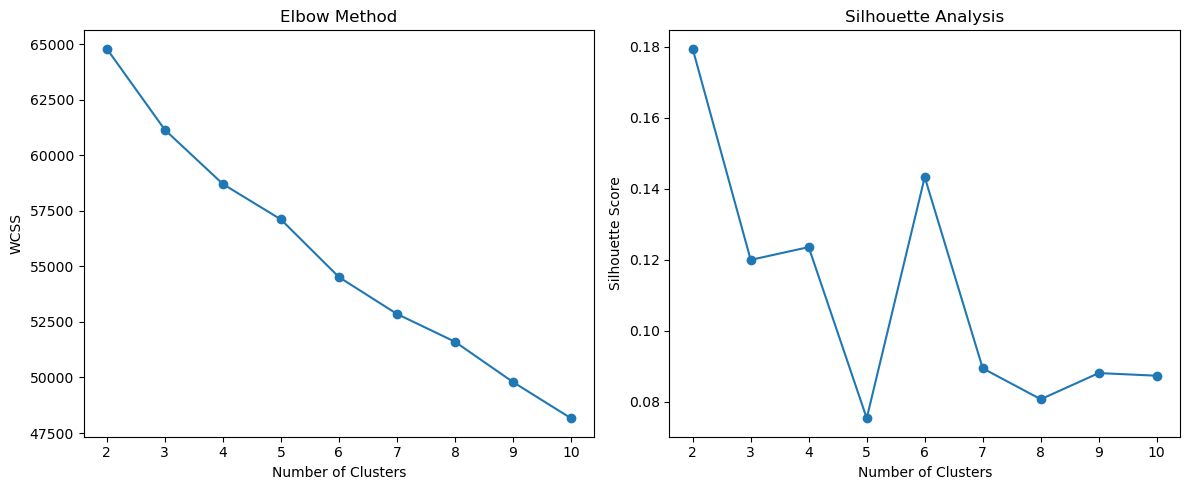

In [50]:
wcss = []
silhouette_scores = []
cluster_range = range(2, 11)
for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)
    
    if n_clusters > 1:  
        silhouette_avg = silhouette_score(scaled_data, kmeans.labels_)
        silhouette_scores.append(silhouette_avg)
        print(f"For n_clusters = {n_clusters}, silhouette score is {silhouette_avg:.4f}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cluster_range, wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.tight_layout()
plt.show()



In [54]:
optimal_clusters = silhouette_scores.index(max(silhouette_scores)) + 2  
optimal_clusters



2

In [56]:
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=20)
clusters = kmeans.fit_predict(scaled_data)
clusters


array([0, 1, 0, ..., 0, 0, 1])

In [60]:
data['Cluster'] = clusters
data['Cluster']


0       0
1       1
2       0
3       1
4       1
       ..
2235    0
2236    1
2237    0
2238    0
2239    1
Name: Cluster, Length: 2240, dtype: int32

In [62]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)
pca_result

array([[ 3.60979118, -0.59573772],
       [-2.34086901, -0.67668317],
       [ 1.71382226, -0.42518987],
       ...,
       [ 1.53640453, -0.08984854],
       [ 1.74919012,  1.18421491],
       [-1.90253699,  1.85212826]])

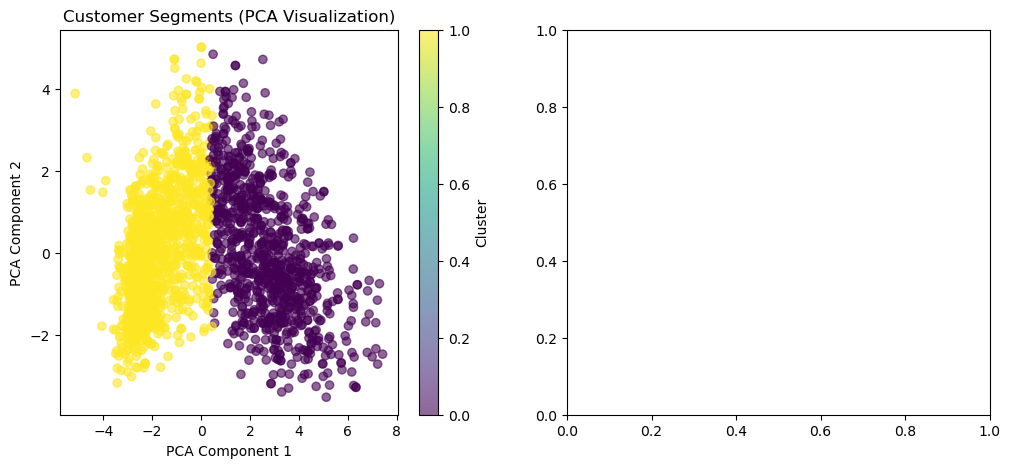

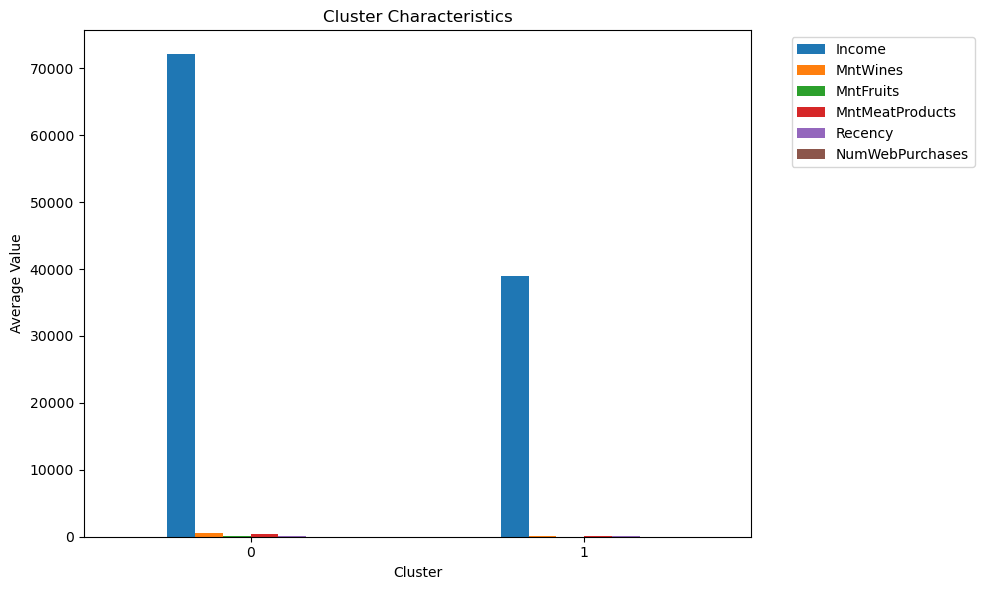

In [76]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Segments (PCA Visualization)')
plt.colorbar(label='Cluster')
numeric_cols = ['Income', 'MntWines', 'MntFruits', 'MntMeatProducts', 'Recency', 'NumWebPurchases']
cluster_analysis = data.groupby('Cluster')[numeric_cols].mean()
plt.subplot(1, 2, 2)
cluster_analysis[numeric_cols].plot(kind='bar', figsize=(10, 6))
plt.title('Cluster Characteristics')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



In [78]:
cluster_sizes = data['Cluster'].value_counts().sort_index()
cluster_sizes


Cluster
0     897
1    1343
Name: count, dtype: int64

In [80]:
cluster_analysis[numeric_cols]


,Income,MntWines,MntFruits,MntMeatProducts,Recency,NumWebPurchases
Cluster,,,,,,
0,72059.142857,604.192865,55.943144,361.289855,49.705686,5.800446
1,38974.627732,103.391660,6.504840,37.148920,48.711095,2.938943


In [82]:
categorical_analysis = data.groupby('Cluster')[['Education', 'Marital_Status']].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown')
categorical_analysis

,Education,Marital_Status
Cluster,,
0,Graduation,Married
1,Graduation,Married


In [84]:
feature_importance = pd.DataFrame({
    'feature': df_processed.columns,
    'importance': np.std(scaled_data, axis=0)  # Using standard deviation as proxy for importance
}).sort_values('importance', ascending=False)
feature_importance.head(10)

,feature,importance
31,Marital_Status_Together,1.0
18,AcceptedCmp1,1.0
16,AcceptedCmp4,1.0
27,Marital_Status_Alone,1.0
23,Education_Basic,1.0
0,Income,1.0
29,Marital_Status_Married,1.0
24,Education_Graduation,1.0
19,AcceptedCmp2,1.0
26,Education_PhD,1.0
